# Solve Burgers' equation based on Fourier Neural Operator

[![DownloadNotebook](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_notebook_en.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/en/data_driven/mindspore_burgers_FNO1D.ipynb)&emsp;[![DownloadCode](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_download_code_en.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/master/mindflow/en/data_driven/mindspore_burgers_FNO1D.py)&emsp;[![ViewSource](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/master/resource/_static/logo_source_en.png)](https://gitee.com/mindspore/docs/blob/master/docs/mindflow/docs/source_en/data_driven/burgers_FNO1D.ipynb)

## Overview

Computational fluid dynamics is one of the most important techniques in the field of fluid mechanics in the 21st century. The flow analysis, prediction and control can be realized by solving the governing equations of fluid mechanics by numerical method. Traditional finite element method (FEM) and finite difference method (FDM) are inefficient because of the complex simulation process (physical modeling, meshing, numerical discretization, iterative solution, etc.) and high computing costs. Therefore, it is necessary to improve the efficiency of fluid simulation with AI.

Machine learning methods provide a new paradigm for scientific computing by providing a fast solver similar to traditional methods. Classical neural networks learn mappings between finite dimensional spaces and can only learn solutions related to a specific discretization. Different from traditional neural networks, Fourier Neural Operator (FNO) is a new deep learning architecture that can learn mappings between infinite-dimensional function spaces. It directly learns mappings from arbitrary function parameters to solutions to solve a class of partial differential equations.  Therefore, it has a stronger generalization capability. More information can be found in the paper, [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/abs/2010.08895).

This tutorial describes how to solve the 1-d Burgers' equation using Fourier neural operator.

## Burgers' equation

The 1-d Burgers’ equation is a non-linear PDE with various applications including modeling the one
dimensional flow of a viscous fluid. It takes the form

$$
\partial_t u(x, t)+\partial_x (u^2(x, t)/2)=\nu \partial_{xx} u(x, t), \quad x \in(0,1), t \in(0, 1]
$$

$$
u(x, 0)=u_0(x), \quad x \in(0,1)
$$

where $u$ is the velocity field, $u_0$ is the initial condition and $\nu$ is the viscosity coefficient.


## Problem Description

We aim to learn the operator mapping the initial condition to the solution at time one:

$$
u_0 \mapsto u(\cdot, 1)
$$

## Technology Path

MindFlow solves the problem as follows:

1. Training Dataset Construction.
2. Model Construction.
3. Optimizer and Loss Function.
4. Model Training.

## Fourier Neural Operator

The Fourier Neural Operator consists of the Lifting Layer, Fourier Layers, and the Decoding Layer.

![Fourier Neural Operator model structure](images/FNO.png)

Fourier layers: Start from input V. On top: apply the Fourier transform $\mathcal{F}$; a linear transform R on the lower Fourier modes and filters out the higher modes; then apply the inverse Fourier transform $\mathcal{F}^{-1}$. On the bottom: apply a local linear transform W.  Finally, the Fourier Layer output vector is obtained through the activation function.

![Fourier Layer structure](images/FNO-2.png)

In [ ]:
import sys
import os
project_root = os.path.abspath("../../../../..")
sys.path.append(project_root)

In [2]:
import sys
sys.path.append("/home/mindspore/work/mindscience_newest")

import os
import time
import numpy as np

from mindspore.amp import DynamicLossScaler, auto_mixed_precision, all_finite
from mindspore import context, nn, Tensor, set_seed, ops, data_sink, jit, save_checkpoint
from mindspore import dtype as mstype
from mindscience import FNO1D, RelativeRMSELoss, load_yaml_config, get_warmup_cosine_annealing_lr
from mindscience.pde import UnsteadyFlowWithLoss

/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/mindspore/miniconda/envs/jupyter/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


The following `src` pacakage can be downloaded in [applications/data_driven/burgers/fno1d/src](https://gitee.com/mindspore/mindscience/tree/master/MindFlow/applications/data_driven/burgers/fno1d/src).

In [3]:
from src import create_training_dataset, visual

set_seed(0)
np.random.seed(0)

context.set_context(mode=context.GRAPH_MODE, device_target="Ascend", device_id=0,max_device_memory="32GB")
use_ascend = context.get_context(attr_key='device_target') == "Ascend"

You can get parameters of model, data and optimizer from `config`.

In [4]:
config = load_yaml_config('./configs/fno1d.yaml')
data_params = config["data"]
model_params = config["model"]
optimizer_params = config["optimizer"]

## Training Dataset Construction

Download the training and test dataset: [data_driven/burgers/dataset](https://download.mindspore.cn/mindscience/mindflow/dataset/applications/data_driven/burgers/dataset/) .

In this case, training datasets and test datasets are generated according to Zongyi Li's dataset in [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/pdf/2010.08895.pdf) . The settings are as follows:

the initial condition $u_0(x)$ is generated according to periodic boundary conditions:

$$
u_0 \sim \mu, \mu=\mathcal{N}\left(0,625(-\Delta+25 I)^{-2}\right)
$$

We set the viscosity to $\nu=0.1$ and solve the equation using a split step method where the heat equation part is solved exactly in Fourier space then the non-linear part is advanced, again in Fourier space, using a very fine forward Euler method. The number of samples in the training set is 1000, and the number of samples in the test set is 200.


In [5]:
# create training dataset
train_dataset = create_training_dataset(data_params, model_params, shuffle=True)

# create test dataset
test_input, test_label = np.load(os.path.join(data_params["root_dir"], "test/inputs.npy")), \
                         np.load(os.path.join(data_params["root_dir"], "test/label.npy"))
test_input = Tensor(np.expand_dims(test_input, -2), mstype.float32)
test_label = Tensor(np.expand_dims(test_label, -2), mstype.float32)

Data preparation finished
input_path:  (1000, 1024, 1)
label_path:  (1000, 1024)


## Model Construction

The network is composed of 1 lifting layer, multiple Fourier layers and 1 decoding layer:

- The Lifting layer corresponds to the `FNO1D.fc0` in the case, and maps the output data $x$ to the high dimension;

- Multi-layer Fourier Layer corresponds to the `FNO1D.fno_seq` in the case. Discrete Fourier transform is used to realize the conversion between time domain and frequency domain;

- The Decoding layer corresponds to `FNO1D.fc1` and `FNO1D.fc2` in the case to obtain the final predictive value.

The initialization of the model based on the network above, parameters can be modified in [configuration file](https://gitee.com/mindspore/mindscience/blob/master/MindFlow/applications/data_driven/burgers/fno1d/configs/fno1d.yaml).

In [6]:
model = FNO1D(in_channels=model_params["in_channels"],
              out_channels=model_params["out_channels"],
              n_modes=model_params["modes"],
              resolutions=model_params["resolutions"],
              hidden_channels=model_params["hidden_channels"],
              n_layers=model_params["depths"],
              projection_channels=4*model_params["hidden_channels"],
              )

model_params_list = []
for k, v in model_params.items():
    model_params_list.append(f"{k}:{v}")
model_name = "_".join(model_params_list)
print(model_name)

name:FNO1D_in_channels:1_out_channels:1_modes:16_resolutions:1024_hidden_channels:64_depths:4


## Optimizer and Loss Function

In [7]:
steps_per_epoch = train_dataset.get_dataset_size()
lr = get_warmup_cosine_annealing_lr(lr_init=optimizer_params["learning_rate"],
                                    last_epoch=optimizer_params["epochs"],
                                    steps_per_epoch=steps_per_epoch,
                                    warmup_epochs=1)
optimizer = nn.Adam(model.trainable_params(), learning_rate=Tensor(lr))

if use_ascend:
    from mindspore.amp import DynamicLossScaler, auto_mixed_precision, all_finite
    loss_scaler = DynamicLossScaler(1024, 2, 100)
    auto_mixed_precision(model, 'O3')
else:
    loss_scaler = None

## Model Training

With **MindSpore version >= 2.0.0**, we can use the functional programming for training neural networks. `MindFlow` provide a training interface for unsteady problems `UnsteadyFlowWithLoss` for model training and evaluation.

In [ ]:
problem = UnsteadyFlowWithLoss(model, loss_fn=RelativeRMSELoss(), data_format="NHWTC")

summary_dir = os.path.join(config["summary"]["summary_dir"], model_name)
print(summary_dir)

def forward_fn(data, label):
    loss = problem.get_loss(data, label)
    if use_ascend:
        loss = loss_scaler.scale(loss)
    return loss

grad_fn = ops.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=False)

@jit
def train_step(data, label):
    loss, grads = grad_fn(data, label)
    if use_ascend:
        loss = loss_scaler.unscale(loss)
        if all_finite(grads):
            grads = loss_scaler.unscale(grads)
    loss = ops.depend(loss, optimizer(grads))
    return loss

sink_process = data_sink(train_step, train_dataset, 1)
ckpt_dir = os.path.join(summary_dir, "ckpt")
if not os.path.exists(ckpt_dir):
    os.makedirs(ckpt_dir)

for epoch in range(1, optimizer_params["epochs"] + 1):
    model.set_train()
    local_time_beg = time.time()
    for _ in range(steps_per_epoch):
        cur_loss = sink_process()
    print(
        f"epoch: {epoch} train loss: {cur_loss.asnumpy():.8f}"\
        f" epoch time: {time.time() - local_time_beg:.2f}s"\
        f" step time: {(time.time() - local_time_beg)/steps_per_epoch:.4f}s")

    if epoch % config['summary']['test_interval'] == 0:
        model.set_train(False)
        print("================================Start Evaluation================================")
        rms_error = problem.get_loss(test_input, test_label)/test_input.shape[0]
        print(f"mean rms_error: {rms_error}")
        print("=================================End Evaluation=================================")
        save_checkpoint(model, os.path.join(ckpt_dir, model_params["name"] + '_epoch' + str(epoch)))

./summary/name:FNO1D_in_channels:1_out_channels:1_modes:16_resolutions:1024_hidden_channels:64_depths:4


[ERROR] CORE(14182,ffffa35e7020,python):2025-11-21-12:48:27.409.781 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_14182/2488151560.py]
[ERROR] CORE(14182,ffffa35e7020,python):2025-11-21-12:48:27.412.318 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_14182/2488151560.py]
[ERROR] CORE(14182,ffffa35e7020,python):2025-11-21-12:48:27.412.373 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_14182/2488151560.py]
[ERROR] CORE(14182,ffffa35e7020,python):2025-11-21-12:48:27.412.551 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_14182/2488151560.py]
[ERROR] CORE(14182,ffffa35e7020,python):2025-11-21-12:48:27.412.600 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_14182/2488151560.py]


..epoch: 1 train loss: 0.23552468 epoch time: 18.98s step time: 0.1518s
epoch: 2 train loss: 0.18982483 epoch time: 2.04s step time: 0.0163s
epoch: 3 train loss: 0.27205247 epoch time: 2.05s step time: 0.0164s
epoch: 4 train loss: 0.34487391 epoch time: 2.04s step time: 0.0163s
epoch: 5 train loss: 0.17643432 epoch time: 2.07s step time: 0.0166s
epoch: 6 train loss: 0.16570295 epoch time: 2.08s step time: 0.0166s
epoch: 7 train loss: 0.14640932 epoch time: 2.08s step time: 0.0167s
epoch: 8 train loss: 0.14050895 epoch time: 2.09s step time: 0.0167s
epoch: 9 train loss: 0.19395757 epoch time: 2.06s step time: 0.0165s
epoch: 10 train loss: 0.16622333 epoch time: 2.08s step time: 0.0166s
================================Start Evaluation================================
mean rms_error: 0.019113144
=================================End Evaluation=================================
epoch: 11 train loss: 0.23629785 epoch time: 2.02s step time: 0.0161s
epoch: 12 train loss: 0.19908370 epoch time: 2

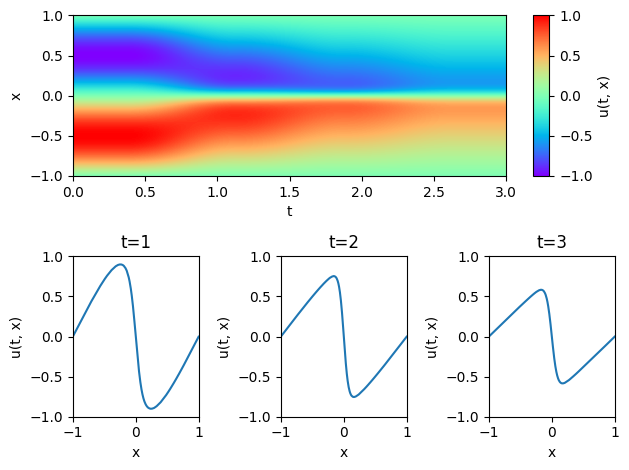

In [9]:
visual(model, epochs=optimizer_params["epochs"], resolution=model_params["resolutions"])